<a href="https://colab.research.google.com/github/14marcos1/pibicjr/blob/main/PYSUS_NO_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PASSO 2 — Verificar se o PySUS está funcionando após o restart

import pysus
import pandas as pd

print("PySUS:", getattr(pysus, "__version__", "?"))
print("pandas:", pd.__version__)
print("✅ Ambiente carregado")

PySUS: 2.0.2
pandas: 2.2.2
✅ Ambiente carregado


In [4]:
# CORREÇÃO — limpar instalação quebrada e instalar PySUS compatível

!pip uninstall -y pysus PySUS
!pip install --no-cache-dir git+https://github.com/AlertaDengue/PySUS.git --upgrade

print("\n✅ Reinstalação concluída.")
print("⚠️ AGORA FAÇA OBRIGATORIAMENTE:")
print("Runtime > Restart runtime")
print("ou Ctrl + M, depois tecla .")

Found existing installation: pysus 2.0.2
Uninstalling pysus-2.0.2:
  Successfully uninstalled pysus-2.0.2
  Cloning https://github.com/AlertaDengue/PySUS.git to /tmp/pip-req-build-8hgkjxjx
  Running command git clone --filter=blob:none --quiet https://github.com/AlertaDengue/PySUS.git /tmp/pip-req-build-8hgkjxjx
  Resolved https://github.com/AlertaDengue/PySUS.git to commit 0920e2754ee2513da5d872d04cc42b1cd1d21678
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pysus: filename=pysus-2.0.2-py3-none-any.whl size=214004 sha256=2010f6b5036d9c2d6a502e1a566918931cb459008e9754e6baf068068415284c
  Stored in directory: /tmp/pip-ephem-wheel-cache-c3hcv1t4/wheels/19/05/be/2766e75f038f7f171dc79787f4b28ac8656c60c8db81db49ac
Successfully built pysus



✅ Reinstalação concluída.
⚠️ AGORA FAÇA OBRIGATORIAMENTE:
Runtime > Restart runtime
ou Ctrl + M, depois tecla .


In [2]:
# PASSO 3 — Baixar SIM/AC 2010–2023 direto do DATASUS
# Gera dois arquivos:
# - mortalidade_ac_neoplasias_2010_2023.csv/xlsx
# - mortalidade_ac_circulatorio_2010_2023.csv/xlsx

!pip install dbfread simpledbf pyreaddbc pandas openpyxl -q

import os
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

UF = "AC"
ANOS = range(2010, 2024)

pasta = Path("/content/dados_mortalidade_ac")
pasta.mkdir(exist_ok=True)

def baixar_arquivo(url, destino):
    if destino.exists() and destino.stat().st_size > 0:
        print(f"   ↪️ Já existe: {destino.name}")
        return True
    try:
        urlretrieve(url, destino)
        print(f"   ✅ Baixado: {destino.name}")
        return True
    except Exception as e:
        print(f"   ❌ Falhou: {url}")
        print(f"      {e}")
        return False

def ler_dbc(caminho_dbc):
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    dbc2dbf(str(caminho_dbc), str(caminho_dbf))
    tabela = DBF(str(caminho_dbf), encoding="latin1", load=True)
    return pd.DataFrame(iter(tabela))

def grupo_cid10(causa):
    if pd.isna(causa):
        return None

    cid = str(causa).strip().upper().replace(".", "")
    if len(cid) < 3:
        return None

    letra = cid[0]

    try:
        numero = int(cid[1:3])
    except:
        return None

    # Neoplasias: CID-10 C00-D48
    if letra == "C":
        return "Neoplasias"
    if letra == "D" and 0 <= numero <= 48:
        return "Neoplasias"

    # Aparelho circulatório: CID-10 I00-I99
    if letra == "I" and 0 <= numero <= 99:
        return "Aparelho Circulatório"

    return "Outros"

dfs = []

print("📥 Iniciando download direto do DATASUS/SIM...")

for ano in ANOS:
    nome = f"DO{UF}{ano}.dbc"
    url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
    caminho_dbc = pasta / nome

    print(f"\nAno {ano}:")
    ok = baixar_arquivo(url, caminho_dbc)

    if not ok:
        continue

    try:
        df_ano = ler_dbc(caminho_dbc)
        df_ano["ANO_ARQUIVO"] = ano
        print(f"   📊 Registros lidos: {len(df_ano):,}")
        dfs.append(df_ano)
    except Exception as e:
        print(f"   ❌ Erro ao ler {nome}: {e}")

if not dfs:
    raise RuntimeError("Nenhum arquivo foi baixado/lido. Pode ser bloqueio temporário do FTP no Colab.")

df = pd.concat(dfs, ignore_index=True)

print("\n✅ Base SIM Acre 2010–2023 carregada")
print(f"📊 Total geral de óbitos: {len(df):,}")
print(f"🧭 Colunas iniciais: {df.columns[:12].tolist()}")

if "CAUSABAS" not in df.columns:
    raise RuntimeError("Coluna CAUSABAS não encontrada. Cole aqui a lista de colunas.")

df["GRUPO_CAUSA"] = df["CAUSABAS"].apply(grupo_cid10)

df_neoplasias = df[df["GRUPO_CAUSA"] == "Neoplasias"].copy()
df_circulatorio = df[df["GRUPO_CAUSA"] == "Aparelho Circulatório"].copy()

print("\n📌 Totais filtrados:")
print(f"Neoplasias / Câncer: {len(df_neoplasias):,} óbitos")
print(f"Aparelho Circulatório / Coração: {len(df_circulatorio):,} óbitos")

# Salvar arquivos
neo_csv = pasta / "mortalidade_ac_neoplasias_2010_2023.csv"
circ_csv = pasta / "mortalidade_ac_circulatorio_2010_2023.csv"

neo_xlsx = pasta / "mortalidade_ac_neoplasias_2010_2023.xlsx"
circ_xlsx = pasta / "mortalidade_ac_circulatorio_2010_2023.xlsx"

df_neoplasias.to_csv(neo_csv, sep=";", index=False, encoding="utf-8-sig")
df_circulatorio.to_csv(circ_csv, sep=";", index=False, encoding="utf-8-sig")

df_neoplasias.to_excel(neo_xlsx, index=False)
df_circulatorio.to_excel(circ_xlsx, index=False)

print("\n💾 Arquivos gerados:")
print(neo_csv)
print(circ_csv)
print(neo_xlsx)
print(circ_xlsx)

print("\n✅ Finalizado. No Colab, abra a pasta lateral:")
print("/content/dados_mortalidade_ac")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.4/479.4 kB 6.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
curl-cffi 0.15.0 requires cffi>=2.0.0, but you have cffi 1.17.1 which is incompatible.
pygit2 1.19.2 requires cffi>=2.0, but you have cffi 1.17.1 which is incompatible.
📥 Iniciando download direto do DATASUS/SIM...

Ano 2010:
   ✅ Baixado: DOAC2010.dbc
   📊 Registros lidos: 3,009

Ano 2011:
   ✅ Baixado: DOAC2011.dbc
   📊 Registros lidos: 3,157

Ano 2012:
   ✅ Baixado: DOAC2012.dbc
   📊 Registros lidos: 3,293

Ano 2013:
   ✅ Baixado: DOAC2013.dbc
   📊 Registros lidos: 3,318

Ano 2014:

/tmp/ipykernel_22683/4166265019.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["GRUPO_CAUSA"] = df["CAUSABAS"].apply(grupo_cid10)



📌 Totais filtrados:
Neoplasias / Câncer: 7,192 óbitos
Aparelho Circulatório / Coração: 11,305 óbitos

💾 Arquivos gerados:
/content/dados_mortalidade_ac/mortalidade_ac_neoplasias_2010_2023.csv
/content/dados_mortalidade_ac/mortalidade_ac_circulatorio_2010_2023.csv
/content/dados_mortalidade_ac/mortalidade_ac_neoplasias_2010_2023.xlsx
/content/dados_mortalidade_ac/mortalidade_ac_circulatorio_2010_2023.xlsx

✅ Finalizado. No Colab, abra a pasta lateral:
/content/dados_mortalidade_ac


In [3]:
import pandas as pd
from pathlib import Path

pasta = Path("/content/dados_mortalidade_ac")

neo = pd.read_csv(pasta / "mortalidade_ac_neoplasias_2010_2023.csv", sep=";")
circ = pd.read_csv(pasta / "mortalidade_ac_circulatorio_2010_2023.csv", sep=";")

print("✅ Neoplasias")
print("Registros:", len(neo))
print("Anos:", neo["ANO_ARQUIVO"].min(), "→", neo["ANO_ARQUIVO"].max())
print("Exemplos CAUSABAS:", neo["CAUSABAS"].dropna().head(10).tolist())

print("\n✅ Aparelho Circulatório")
print("Registros:", len(circ))
print("Anos:", circ["ANO_ARQUIVO"].min(), "→", circ["ANO_ARQUIVO"].max())
print("Exemplos CAUSABAS:", circ["CAUSABAS"].dropna().head(10).tolist())

✅ Neoplasias
Registros: 7192
Anos: 2010 → 2023
Exemplos CAUSABAS: ['C414', 'C221', 'C80', 'C787', 'C449', 'C55', 'C169', 'C437', 'C61', 'C20']

✅ Aparelho Circulatório
Registros: 11305
Anos: 2010 → 2023
Exemplos CAUSABAS: ['I219', 'I64', 'I219', 'I10', 'I219', 'I219', 'I219', 'I10', 'I690', 'I690']


/tmp/ipykernel_22683/323774532.py:7: DtypeWarning: Columns (54,98) have mixed types. Specify dtype option on import or set low_memory=False.
  circ = pd.read_csv(pasta / "mortalidade_ac_circulatorio_2010_2023.csv", sep=";")


📊 Tabela comparativa:


/tmp/ipykernel_22683/1726685143.py:12: DtypeWarning: Columns (54,98) have mixed types. Specify dtype option on import or set low_memory=False.
  circ = pd.read_csv(pasta / "mortalidade_ac_circulatorio_2010_2023.csv", sep=";")


,ANO_ARQUIVO,Neoplasias / Câncer,Aparelho Circulatório / Coração
0,2010,331,606
1,2011,380,715
2,2012,470,659
3,2013,470,698
4,2014,496,762
5,2015,494,849
6,2016,508,834
7,2017,574,856
8,2018,595,910
9,2019,561,926


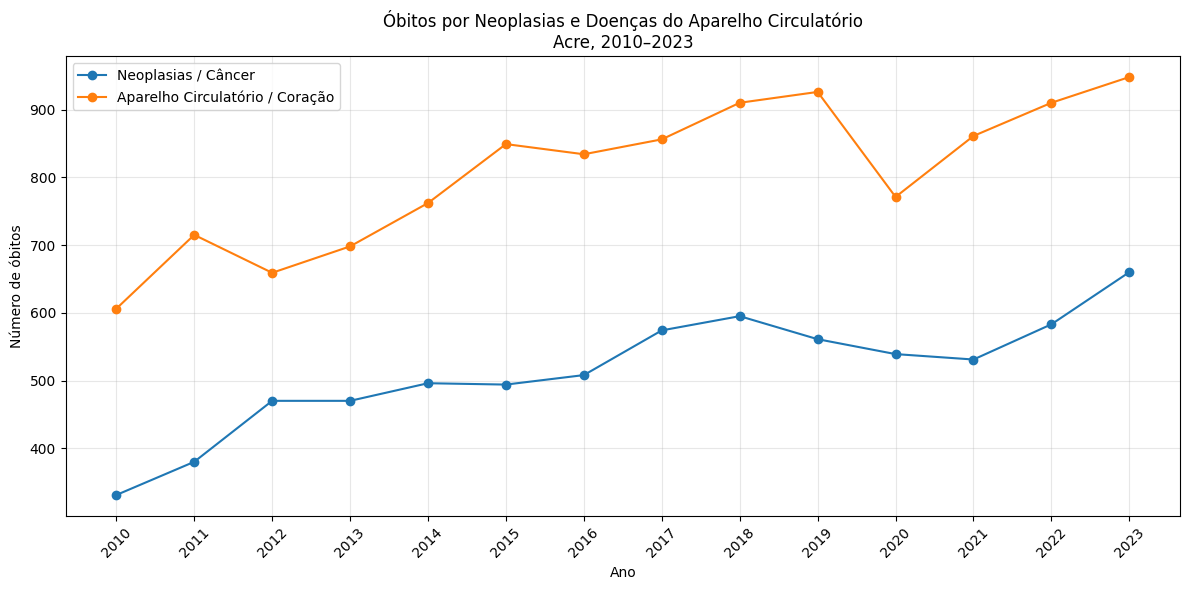

In [4]:
# PASSO 5 — Gráfico comparativo ano a ano
# Compara Neoplasias vs Aparelho Circulatório no Acre, 2010–2023

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pasta = Path("/content/dados_mortalidade_ac")

# Carregar os dois arquivos
neo = pd.read_csv(pasta / "mortalidade_ac_neoplasias_2010_2023.csv", sep=";")
circ = pd.read_csv(pasta / "mortalidade_ac_circulatorio_2010_2023.csv", sep=";")

# Contar óbitos por ano
serie_neo = neo.groupby("ANO_ARQUIVO").size().reset_index(name="Neoplasias / Câncer")
serie_circ = circ.groupby("ANO_ARQUIVO").size().reset_index(name="Aparelho Circulatório / Coração")

# Juntar as duas séries
comparativo = pd.merge(
    serie_neo,
    serie_circ,
    on="ANO_ARQUIVO",
    how="outer"
).sort_values("ANO_ARQUIVO")

comparativo = comparativo.fillna(0)

print("📊 Tabela comparativa:")
display(comparativo)

# Gráfico de linhas
plt.figure(figsize=(12, 6))

plt.plot(
    comparativo["ANO_ARQUIVO"],
    comparativo["Neoplasias / Câncer"],
    marker="o",
    label="Neoplasias / Câncer"
)

plt.plot(
    comparativo["ANO_ARQUIVO"],
    comparativo["Aparelho Circulatório / Coração"],
    marker="o",
    label="Aparelho Circulatório / Coração"
)

plt.title("Óbitos por Neoplasias e Doenças do Aparelho Circulatório\nAcre, 2010–2023")
plt.xlabel("Ano")
plt.ylabel("Número de óbitos")
plt.xticks(comparativo["ANO_ARQUIVO"], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()